In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

## Загрузка и первичный осмотр данных

Чтение датасета и базовый анализ структуры: первые строки, информация о типах данных, статистические характеристики числовых признаков.


In [38]:
df = pd.read_csv('ford.csv')
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [40]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


## Очистка данных: коррекция выбросов

Функция для замены некорректных значений года выпуска (>2026) на медианное значение признака.


In [41]:
def real_year(year):
    if year > 2026:
        return df.year.median()
    return year

In [42]:
df.year = df.year.apply(real_year)

## Анализ корреляций

Тепловая матрица коэффициентов корреляции Пирсона для числовых признаков. Позволяет выявить линейные зависимости между переменными.

<Axes: >

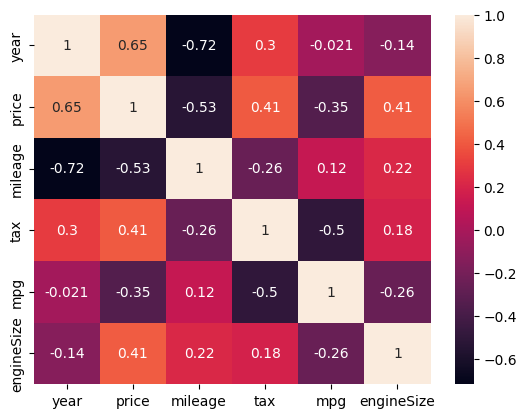

In [43]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## Распределение целевой переменной

Гистограмма с оценкой плотности (KDE) для переменной `price`. Визуализация помогает оценить нормальность распределения и наличие выбросов.

<Axes: xlabel='price', ylabel='Count'>

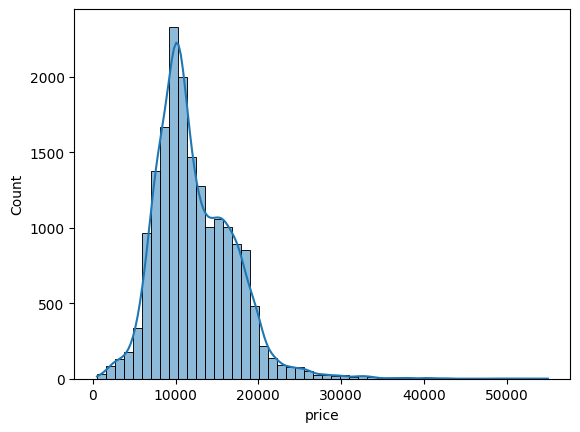

In [44]:
sns.histplot(df['price'], kde=True, bins = 50)

## Зависимость цены от года выпуска

Box plot для анализа распределения цен по годам. Позволяет оценить тренд изменения стоимости автомобилей со временем и выявить аномалии.

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, '1996.0'),
  Text(1, 0, '1998.0'),
  Text(2, 0, '2000.0'),
  Text(3, 0, '2002.0'),
  Text(4, 0, '2003.0'),
  Text(5, 0, '2004.0'),
  Text(6, 0, '2005.0'),
  Text(7, 0, '2006.0'),
  Text(8, 0, '2007.0'),
  Text(9, 0, '2008.0'),
  Text(10, 0, '2009.0'),
  Text(11, 0, '2010.0'),
  Text(12, 0, '2011.0'),
  Text(13, 0, '2012.0'),
  Text(14, 0, '2013.0'),
  Text(15, 0, '2014.0'),
  Text(16, 0, '2015.0'),
  Text(17, 0, '2016.0'),
  Text(18, 0, '2017.0'),
  Text(19, 0, '2018.0'),
  Text(20, 0, '2019.0'),
  Text(21, 0, '2020.0')])

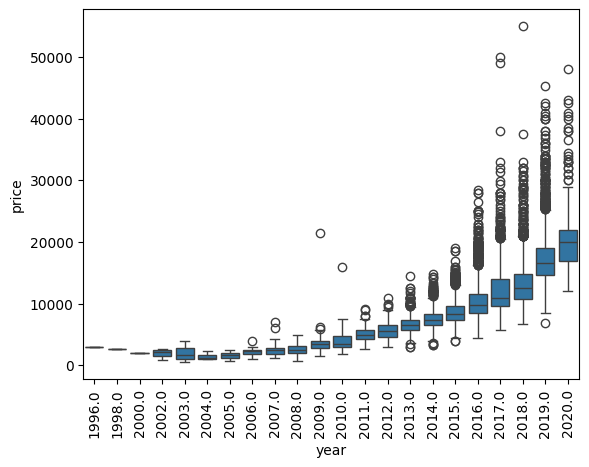

In [45]:
sns.boxplot(data = df, x = 'year', y = 'price')
plt.xticks(rotation=90)

## Зависимость цены от пробега

Scatter plot для визуализации связи между пробегом и ценой. Позволяет оценить характер зависимости и наличие выбросов.


(array([-25000.,      0.,  25000.,  50000.,  75000., 100000., 125000.,
        150000., 175000., 200000.]),
 [Text(-25000.0, 0, '−25000'),
  Text(0.0, 0, '0'),
  Text(25000.0, 0, '25000'),
  Text(50000.0, 0, '50000'),
  Text(75000.0, 0, '75000'),
  Text(100000.0, 0, '100000'),
  Text(125000.0, 0, '125000'),
  Text(150000.0, 0, '150000'),
  Text(175000.0, 0, '175000'),
  Text(200000.0, 0, '200000')])

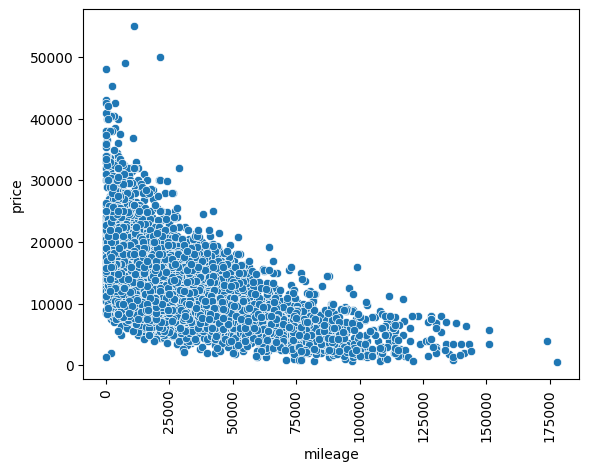

In [46]:
sns.scatterplot(data = df, x = 'mileage', y = 'price')
plt.xticks(rotation = 90)

## Кодирование категориальных признаков

Преобразование текстовых признаков (`model`, `transmission`, `fuelType`) в числовой формат с помощью one-hot encoding (`pd.get_dummies`).


In [49]:
df = pd.get_dummies(df, dtype=np.int8)

In [54]:
X = df.drop('price', axis = 1)
y = df.price

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=42, train_size=0.3)

## Базовая модель: линейная регрессия

Обучение модели `LinearRegression` без предобработки признаков. Оценка качества по метрике R² на тестовой выборке.

In [56]:
lr = LinearRegression(tol = 1e-6)

In [57]:
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
r2_score(lr.predict(X_test), y_test)

0.7950596950880088

## Масштабирование признаков

Стандартизация данных с помощью `StandardScaler` для приведения признаков к единому масштабу (mean=0, std=1).


In [60]:
scale = StandardScaler()

In [61]:
scale.fit(X_train, y_train)

,copy,True
,with_mean,True
,with_std,True


In [64]:
X_train_scale = scale.transform(X_train)
X_test_scale = scale.transform(X_test)

## Линейная регрессия на масштабированных данных

Обучение модели на нормализованных признаках. Сравнение метрик с базовой моделью для оценки влияния масштабирования.


In [65]:
lr_scale = LinearRegression(tol = 1e-6)

In [66]:
lr_scale.fit(X_train_scale, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [69]:
r2_score(lr_scale.predict(X_test_scale), y_test) 

0.7950596950882046

## Градиентный бустинг: подбор гиперпараметров

Поиск оптимальных гиперпараметров для `GradientBoostingRegressor` с помощью `GridSearchCV`. Параметры: функция потерь, скорость обучения, число деревьев, критерий разбиения, глубина дерева

In [70]:
gb = GradientBoostingRegressor()

In [76]:
params = {
    'loss': ['squared_error', 'absolute_error', 'huber', 'quantile'],
    'learning_rate': [0., 0.1, 0.2, 0.3, 0.4, 0.5, 1.],
    'n_estimators': range(50, 250, 50),
    'criterion': ['friedman_mse', 'squared_error'],
    'max_depth': range(2, 11, 2),
}

In [77]:
clf = GridSearchCV(gb, params, cv = 3, n_jobs=5, verbose=2)

In [78]:
clf.fit(X_train_scale, y_train)

Fitting 3 folds for each of 1120 candidates, totalling 3360 fits


,estimator,GradientBoostingRegressor()
,param_grid,"{'criterion': ['friedman_mse', 'squared_error'], 'learning_rate': [0.0, 0.1, ...], 'loss': ['squared_error', 'absolute_error', ...], 'max_depth': range(2, 11, 2), ...}"
,scoring,None
,n_jobs,5
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'absolute_error'


In [79]:
r2_score(clf.best_estimator_.predict(X_test_scale), y_test) 

0.895711489466139

## Подготовка данных для CatBoost

Загрузка исходного датасета с сохранением категориальных признаков для нативной обработки библиотекой CatBoost.


In [80]:
df_cat = pd.read_csv('ford.csv')

In [87]:
X = df_cat.drop('price', axis = 1)
y = df_cat.price

In [91]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=42, train_size=0.3)

## Сетка гиперпараметров для CatBoost

Определение пространства поиска: число итераций, глубина дерева, скорость обучения, коэффициент L2-регуляризации.

In [92]:
param_grid = {
    'iterations': [100, 500, 1000],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}

In [96]:
CAT_F = ['model', 'transmission', 'fuelType']

In [97]:
model = CatBoostRegressor(cat_features= CAT_F, verbose=0, random_seed=42)

In [100]:
grid_search = GridSearchCV(model, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=2)

In [101]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


,estimator,<catboost.cor...002049B2687D0>
,param_grid,"{'depth': [4, 6, ...], 'iterations': [100, 500, ...], 'l2_leaf_reg': [1, 3, ...], 'learning_rate': [0.01, 0.05, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


In [102]:
grid_search.best_params_

{'depth': 6, 'iterations': 1000, 'l2_leaf_reg': 1, 'learning_rate': 0.05}

## Финальная оценка модели CatBoost

Расчёт метрики R² на тестовой выборке для лучшей модели, найденной в ходе подбора гиперпараметров.

In [103]:
r2_score(grid_search.best_estimator_.predict(X_test), y_test)

0.9669552704194894